# Model Training Tests

In [3]:
# Libraries and functions
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from models import *


# def preprocessing_input(x, labels, device='cpu', model='MLP'):
#     """
#     Preprocesses input data based on the model type and input dimensionality.

#     Args:
#         x (torch.Tensor): Input data tensor.
#         labels (torch.Tensor): Target labels tensor.
#         device (str): Device to move tensors to ('cpu' or 'cuda').
#         model (nn.Module): The model instance.

#     Returns:
#         tuple: Processed input tensor and labels tensor moved to the specified device.
#     """
#     model_name = model.__class__.__name__

#     if model_name in ['CNN', 'ResNet9', 'LeNet5Flexible']:
#         # CNNs and similar models expect 4D input tensors with shape (batch_size, channels, height, width)
#         if x.dim() == 4:
#             return x.to(device), labels.to(device)
#         else:
#             raise ValueError("For CNN-based models, expected a 4D tensor with shape (batch_size, channels, height, width).")
    
#     elif model_name in ['MLP', 'LinearModel']:
#         # MLPs and linear models expect 2D input tensors
#         if x.dim() == 4:  # Flatten image data
#             return x.view(x.size(0), -1).to(device), labels.to(device)
#         elif x.dim() == 2:  # Tabular data
#             return x.to(device), labels.to(device)
#         else:
#             raise ValueError("For MLP/LinearModel, expected either 4D tensor (batch_size, channels, height, width) or 2D tensor (batch_size, num_features).")
    
#     elif model_name in ['TransformerModelFlexible']:
#         # Transformers expect 3D input tensors with shape (batch_size, sequence_length, input_dim)
#         if x.dim() == 3:
#             return x.to(device), labels.to(device)
#         elif x.dim() == 4:  # Handle image data by flattening spatial dimensions
#             batch_size, channels, height, width = x.size()
#             x_flat = x.view(batch_size, channels * height * width).unsqueeze(1)  # Treat flattened image as a sequence
#             print(x_flat.size())
#             return x_flat.to(device), labels.to(device)
#         elif x.dim() == 2:  # Tabular data
#             return x.unsqueeze(2).to(device), labels.to(device)  # Treat tabular data as a sequence of length 1
#         else:
#             raise ValueError("For TransformerModelFlexible, expected a 3D tensor (batch_size, sequence_length, input_dim), 4D tensor (batch_size, channels, height, width), or 2D tensor (batch_size, num_features).")
    
#     else:
#         raise ValueError(f"Unsupported model type: {model_name}")
    
def preprocessing_input(x, labels, device='cpu', model='MLP'):
    """
    Preprocesses input data based on the model type and input dimensionality.

    Args:
        x (torch.Tensor): Input data tensor.
        labels (torch.Tensor): Target labels tensor.
        device (str): Device to move tensors to ('cpu' or 'cuda').
        model (nn.Module): The model instance.

    Returns:
        tuple: Processed input tensor and labels tensor moved to the specified device.
    """
    
    # Get the model name
    model_name = model.__class__.__name__

    # Preprocess input data based on the model type
    if model_name in ['CNN', 'ResNet9', 'LeNet5Flexible']:
        # CNNs and similar models expect 4D input tensors with shape (batch_size, channels, height, width)
        if x.dim() == 4:
            return x.to(device), labels.to(device)
        elif x.dim() == 3:  # Handle time series data by adding a channel dimension
            return x.unsqueeze(1).to(device), labels.to(device)
        elif x.dim() == 2:  # Handle tabular data by adding channel, height, and width dimensions
            return x.unsqueeze(1).unsqueeze(2).unsqueeze(3).to(device), labels.to(device)
        else:
            raise ValueError("For CNN-based models, expected a 4D tensor with shape (batch_size, channels, height, width).")
    
    elif model_name in ['MLP', 'LinearModel']:
        # MLPs and linear models expect 2D input tensors
        if x.dim() == 4:  # Flatten image data
            return x.view(x.size(0), -1).to(device), labels.to(device)
        elif x.dim() == 3:  # Time series data
            return x.view(x.size(0), x.size(1) * x.size(2)).to(device), labels.to(device)
        elif x.dim() == 2:  # Tabular data
            return x.to(device), labels.to(device)
        else:
            raise ValueError("For MLP/LinearModel, expected either 4D tensor (batch_size, channels, height, width) or 2D tensor (batch_size, num_features).")
    
    elif model_name in ['TransformerModelFlexible']:
        # Transformers expect 3D input tensors with shape (batch_size, sequence_length, input_dim)
        if x.dim() == 4:  # Handle image data by flattening spatial dimensions
            batch_size, channels, height, width = x.size()
            x_flat = x.view(batch_size, channels * height * width).unsqueeze(2)  # Treat flattened image as a sequence
            return x_flat.to(device), labels.to(device)
        elif x.dim() == 3: # Time series data
            return x.to(device), labels.to(device)
        elif x.dim() == 2:  # Tabular data
            return x.unsqueeze(2).to(device), labels.to(device)  # Treat tabular as a sequence and 1 feature 
        else:
            raise ValueError("For TransformerModelFlexible, expected a 3D tensor (batch_size, sequence_length, input_dim), 4D tensor (batch_size, channels, height, width), or 2D tensor (batch_size, num_features).")
    
    else:
        raise ValueError(f"Unsupported model type: {model_name}")
    

def evaluate_test(model, test_loader, device='cpu'):
    model.eval()
    actuals, predictions = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = preprocessing_input(images, labels, device, model)
            outputs = model(images)
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)
                predictions.append(outputs.cpu().numpy().flatten())
                actuals.append(labels.cpu().numpy().flatten())
            elif model.task_type == 'classification':
                labels = labels.long()
                predictions.append(outputs.cpu().numpy())
                actuals.append(labels.cpu().numpy())

    predictions = np.concatenate(predictions)
    actuals = np.concatenate(actuals)
    
    if model.task_type == 'regression':
        # Calculate regression metrics
        mse = mean_squared_error(actuals, predictions)
        r2 = r2_score(actuals, predictions)
        
        print(f' - Mean Squared Error: {mse:.4f}')
        print(f' - R² Score: {r2:.4f}')
        
        return mse, r2
    
    elif model.task_type == 'classification':
        if predictions.shape[1] == 1:
            # Binary classification (with only 1 output): use thresholding
            predicted_classes = (predictions > 0.5).astype(int).flatten()
            actual_classes = actuals.flatten()
        else:
            # Multi-class classification: apply argmax to get predicted classes
            predicted_classes = np.argmax(predictions, axis=1)
            actual_classes = actuals
            
        # Calculate classification metrics
        accuracy = accuracy_score(actual_classes, predicted_classes)
        precision = precision_score(actual_classes, predicted_classes, average='weighted')
        recall = recall_score(actual_classes, predicted_classes, average='weighted')
        f1 = f1_score(actual_classes, predicted_classes, average='weighted')
        
        print(f' - Accuracy: {accuracy:.4f}')
        print(f' - Precision: {precision:.4f}')
        print(f' - Recall: {recall:.4f}')
        print(f' - F1 Score: {f1:.4f}')
        
        return accuracy, precision, recall, f1

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cpu'):
    best_model = None
    best_val_loss = float('inf')
    final_model = None
    metrics = {'loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = preprocessing_input(images, labels, device, model)  # Flatten the image according to its dimensionality
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)  # Convert labels to float for regression
            elif model.task_type == 'classification':
                labels = labels.long()  # Ensure labels are in long format for classification
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        
        # Calculate average training loss
        epoch_loss = running_loss / len(train_loader.dataset)
        metrics['loss'].append(epoch_loss)
        
        # Evaluate on the validation set
        val_loss = evaluate(model, val_loader, criterion, device=device)
        metrics['val_loss'].append(val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Check if this is the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())  # Save the best model
    
    # Load the best model for return
    model.load_state_dict(best_model)
    
    return model, metrics

def evaluate(model, val_loader, criterion, device='cpu'):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = preprocessing_input(images, labels, device, model)
            
            if model.task_type == 'regression':
                labels = labels.float().view(-1, 1)
            elif model.task_type == 'classification':
                labels = labels.long()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
    
    return val_loss / len(val_loader.dataset)

def plot_training_metrics(metrics, dataset):
    # Extract losses
    epochs = list(range(1, len(metrics['loss']) + 1))
    train_losses = metrics['loss']
    val_losses = metrics['val_loss']
    
    # Find the epoch with the minimum validation loss
    min_val_loss_epoch = val_losses.index(min(val_losses)) + 1
    min_val_loss = min(val_losses)
    
    # Create a plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=epochs, y=train_losses, label='Training Loss')
    sns.lineplot(x=epochs, y=val_losses, label='Validation Loss')
    
    # Mark the minimum validation loss with a star
    plt.scatter(min_val_loss_epoch, min_val_loss, color='red', marker='*', s=200, label='Min Validation Loss')
    
    # Add titles and labels
    plt.title(f'Training and Validation Loss - {dataset.upper()}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    if not os.path.exists('./images'):
        os.makedirs('./images')
    plt.savefig(f'./images/{dataset}_training_loss.png')
    plt.show()

## 1) Linear Regressor

MPS is available


Training on MNIST dataset
Epoch [1/30], Loss: 0.4134, Val Loss: 0.3081
Epoch [2/30], Loss: 0.2978, Val Loss: 0.3005
Epoch [3/30], Loss: 0.2853, Val Loss: 0.2891
Epoch [4/30], Loss: 0.2769, Val Loss: 0.2875
Epoch [5/30], Loss: 0.2712, Val Loss: 0.2846
Epoch [6/30], Loss: 0.2667, Val Loss: 0.2919
Epoch [7/30], Loss: 0.2641, Val Loss: 0.2843
Epoch [8/30], Loss: 0.2622, Val Loss: 0.2948
Epoch [9/30], Loss: 0.2589, Val Loss: 0.2961
Epoch [10/30], Loss: 0.2580, Val Loss: 0.2947
Epoch [11/30], Loss: 0.2562, Val Loss: 0.2924
Epoch [12/30], Loss: 0.2544, Val Loss: 0.2891
Epoch [13/30], Loss: 0.2527, Val Loss: 0.2898
Epoch [14/30], Loss: 0.2514, Val Loss: 0.2935
Epoch [15/30], Loss: 0.2509, Val Loss: 0.2889
Epoch [16/30], Loss: 0.2484, Val Loss: 0.2951
Epoch [17/30], Loss: 0.2487, Val Loss: 0.2954
Epoch [18/30], Loss: 0.2482, Val Loss: 0.2964
Epoch [19/30], Loss: 0.2467, Val Loss: 0.3068
Epoch [20/30], Loss: 0.2447, Val Loss: 0.2973
Epoch [21/30], Loss: 0.2450, Val Loss: 0.308

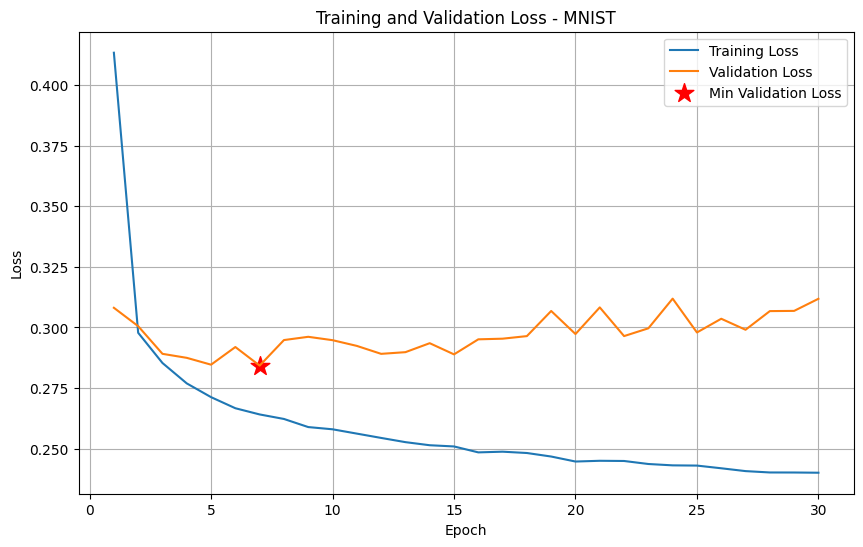

 - Accuracy: 0.9229
 - Precision: 0.9231
 - Recall: 0.9229
 - F1 Score: 0.9228


Training on CIFAR10 dataset
Epoch [1/30], Loss: 1.9820, Val Loss: 1.9650
Epoch [2/30], Loss: 1.9016, Val Loss: 2.0034
Epoch [3/30], Loss: 1.8719, Val Loss: 1.9421
Epoch [4/30], Loss: 1.8498, Val Loss: 1.9616
Epoch [5/30], Loss: 1.8446, Val Loss: 2.0107
Epoch [6/30], Loss: 1.8464, Val Loss: 1.9677
Epoch [7/30], Loss: 1.8335, Val Loss: 2.0678
Epoch [8/30], Loss: 1.8341, Val Loss: 2.0233
Epoch [9/30], Loss: 1.8213, Val Loss: 2.0420
Epoch [10/30], Loss: 1.8082, Val Loss: 2.0367
Epoch [11/30], Loss: 1.8152, Val Loss: 1.9751
Epoch [12/30], Loss: 1.8073, Val Loss: 2.0521
Epoch [13/30], Loss: 1.8069, Val Loss: 1.9746
Epoch [14/30], Loss: 1.7931, Val Loss: 1.9597
Epoch [15/30], Loss: 1.7946, Val Loss: 2.1184
Epoch [16/30], Loss: 1.7948, Val Loss: 1.9857
Epoch [17/30], Loss: 1.7925, Val Loss: 2.0631
Epoch [18/30], Loss: 1.7919, Val Loss: 2.0001
Epoch [19/30], Loss: 1.7855, Val Loss: 2.0340
Epoch [20/30], Loss: 1.782

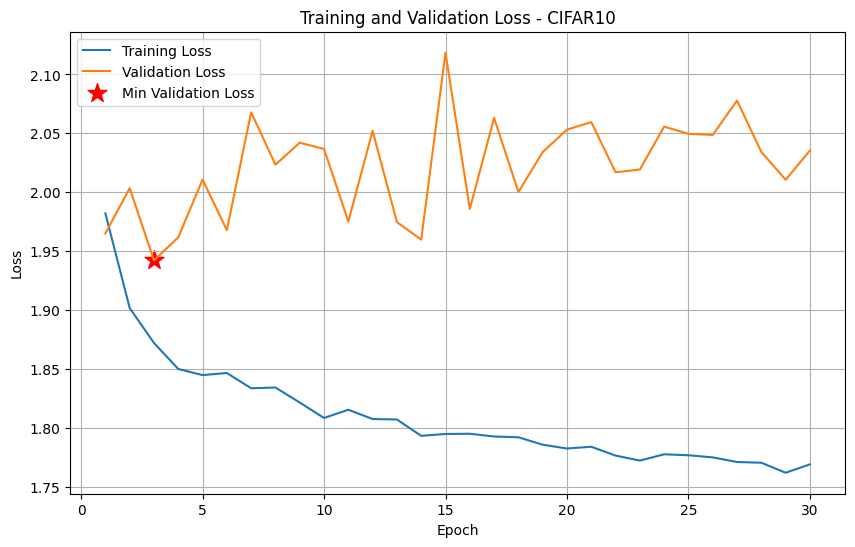

 - Accuracy: 0.3661
 - Precision: 0.3609
 - Recall: 0.3661
 - F1 Score: 0.3608


Training on AIRLINE dataset
Epoch [1/1000], Loss: 0.6164, Val Loss: 0.5718
Epoch [2/1000], Loss: 0.5810, Val Loss: 0.5552
Epoch [3/1000], Loss: 0.5484, Val Loss: 0.5406
Epoch [4/1000], Loss: 0.5193, Val Loss: 0.5281
Epoch [5/1000], Loss: 0.4939, Val Loss: 0.5176
Epoch [6/1000], Loss: 0.4710, Val Loss: 0.5085
Epoch [7/1000], Loss: 0.4510, Val Loss: 0.5010
Epoch [8/1000], Loss: 0.4334, Val Loss: 0.4948
Epoch [9/1000], Loss: 0.4187, Val Loss: 0.4898
Epoch [10/1000], Loss: 0.4048, Val Loss: 0.4851
Epoch [11/1000], Loss: 0.3935, Val Loss: 0.4803
Epoch [12/1000], Loss: 0.3829, Val Loss: 0.4754
Epoch [13/1000], Loss: 0.3733, Val Loss: 0.4705
Epoch [14/1000], Loss: 0.3647, Val Loss: 0.4662
Epoch [15/1000], Loss: 0.3568, Val Loss: 0.4626
Epoch [16/1000], Loss: 0.3502, Val Loss: 0.4593
Epoch [17/1000], Loss: 0.3436, Val Loss: 0.4548
Epoch [18/1000], Loss: 0.3375, Val Loss: 0.4492
Epoch [19/1000], Loss: 0.3317, Val L

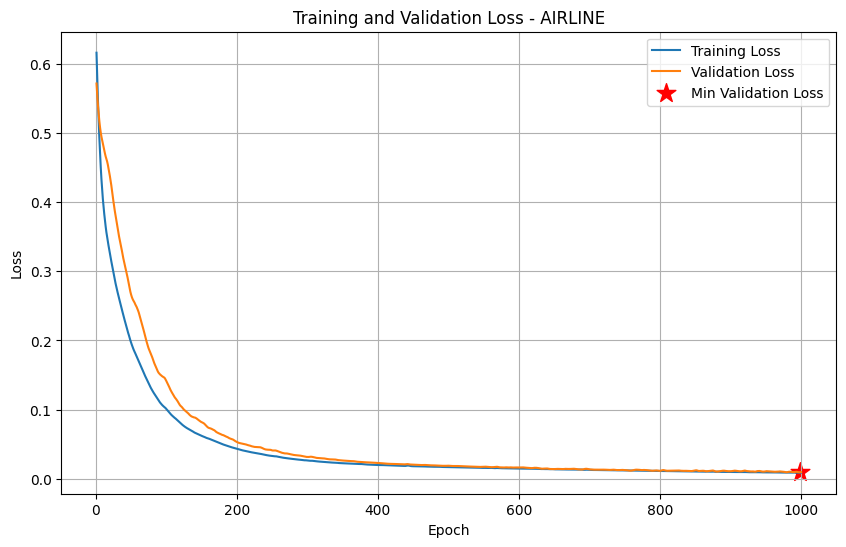

 - Mean Squared Error: 0.0395
 - R² Score: 0.8960


Training on ADULT dataset
Epoch [1/150], Loss: 0.4590, Val Loss: 0.3737
Epoch [2/150], Loss: 0.3492, Val Loss: 0.3478
Epoch [3/150], Loss: 0.3343, Val Loss: 0.3395
Epoch [4/150], Loss: 0.3283, Val Loss: 0.3347
Epoch [5/150], Loss: 0.3250, Val Loss: 0.3321
Epoch [6/150], Loss: 0.3230, Val Loss: 0.3302
Epoch [7/150], Loss: 0.3217, Val Loss: 0.3289
Epoch [8/150], Loss: 0.3208, Val Loss: 0.3281
Epoch [9/150], Loss: 0.3202, Val Loss: 0.3275
Epoch [10/150], Loss: 0.3198, Val Loss: 0.3274
Epoch [11/150], Loss: 0.3193, Val Loss: 0.3274
Epoch [12/150], Loss: 0.3193, Val Loss: 0.3271
Epoch [13/150], Loss: 0.3190, Val Loss: 0.3270
Epoch [14/150], Loss: 0.3191, Val Loss: 0.3271
Epoch [15/150], Loss: 0.3188, Val Loss: 0.3268
Epoch [16/150], Loss: 0.3187, Val Loss: 0.3269
Epoch [17/150], Loss: 0.3187, Val Loss: 0.3266
Epoch [18/150], Loss: 0.3186, Val Loss: 0.3268
Epoch [19/150], Loss: 0.3185, Val Loss: 0.3268
Epoch [20/150], Loss: 0.3184, Val Loss

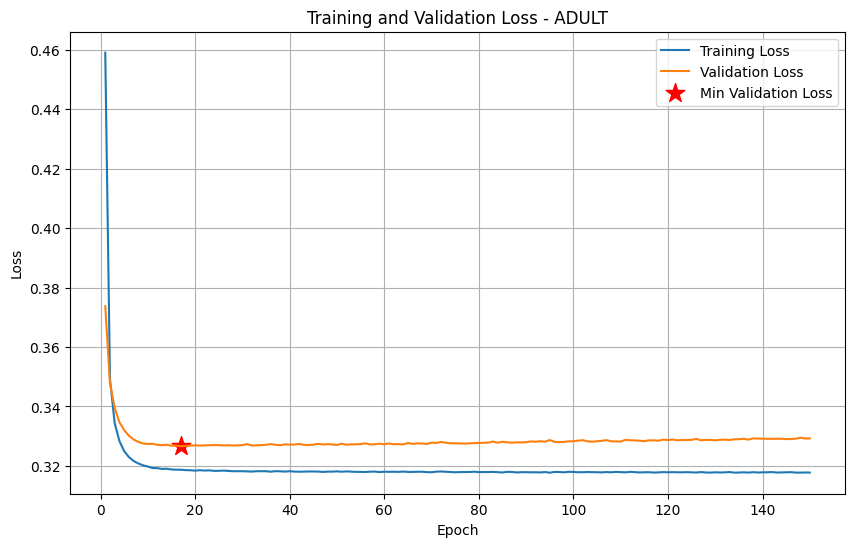

 - Accuracy: 0.8560
 - Precision: 0.8498
 - Recall: 0.8560
 - F1 Score: 0.8502


In [9]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'airline', 'adult']
EPOCHS = [30,30,1000,150]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = LinearModel(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")


## 2) Multilayer Perceptron (MLP)

MPS is available


Training on MNIST dataset
Epoch [1/25], Loss: 0.2830, Val Loss: 0.1512
Epoch [2/25], Loss: 0.1192, Val Loss: 0.1117
Epoch [3/25], Loss: 0.0858, Val Loss: 0.0982
Epoch [4/25], Loss: 0.0632, Val Loss: 0.0968
Epoch [5/25], Loss: 0.0490, Val Loss: 0.0950
Epoch [6/25], Loss: 0.0400, Val Loss: 0.1037
Epoch [7/25], Loss: 0.0349, Val Loss: 0.0911
Epoch [8/25], Loss: 0.0289, Val Loss: 0.1066
Epoch [9/25], Loss: 0.0243, Val Loss: 0.1063
Epoch [10/25], Loss: 0.0230, Val Loss: 0.1145
Epoch [11/25], Loss: 0.0217, Val Loss: 0.1061
Epoch [12/25], Loss: 0.0201, Val Loss: 0.1319
Epoch [13/25], Loss: 0.0199, Val Loss: 0.1162
Epoch [14/25], Loss: 0.0160, Val Loss: 0.1329
Epoch [15/25], Loss: 0.0153, Val Loss: 0.1417
Epoch [16/25], Loss: 0.0136, Val Loss: 0.1186
Epoch [17/25], Loss: 0.0127, Val Loss: 0.1210
Epoch [18/25], Loss: 0.0169, Val Loss: 0.1285
Epoch [19/25], Loss: 0.0131, Val Loss: 0.1325
Epoch [20/25], Loss: 0.0116, Val Loss: 0.1325
Epoch [21/25], Loss: 0.0130, Val Loss: 0.127

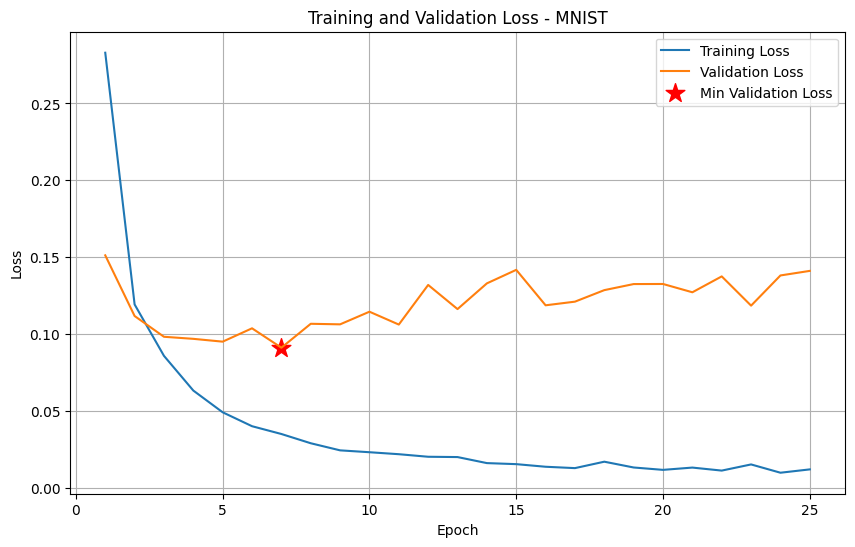

 - Accuracy: 0.9784
 - Precision: 0.9785
 - Recall: 0.9784
 - F1 Score: 0.9784


Training on CIFAR10 dataset
Epoch [1/25], Loss: 1.6715, Val Loss: 1.5908
Epoch [2/25], Loss: 1.4692, Val Loss: 1.5171
Epoch [3/25], Loss: 1.3697, Val Loss: 1.4998
Epoch [4/25], Loss: 1.2970, Val Loss: 1.4733
Epoch [5/25], Loss: 1.2316, Val Loss: 1.4705
Epoch [6/25], Loss: 1.1687, Val Loss: 1.4905
Epoch [7/25], Loss: 1.1174, Val Loss: 1.4822
Epoch [8/25], Loss: 1.0636, Val Loss: 1.4944
Epoch [9/25], Loss: 1.0154, Val Loss: 1.5364
Epoch [10/25], Loss: 0.9750, Val Loss: 1.5630
Epoch [11/25], Loss: 0.9292, Val Loss: 1.5865
Epoch [12/25], Loss: 0.8915, Val Loss: 1.6228
Epoch [13/25], Loss: 0.8539, Val Loss: 1.6616
Epoch [14/25], Loss: 0.8108, Val Loss: 1.7306
Epoch [15/25], Loss: 0.7805, Val Loss: 1.7961
Epoch [16/25], Loss: 0.7466, Val Loss: 1.8242
Epoch [17/25], Loss: 0.7151, Val Loss: 1.8874
Epoch [18/25], Loss: 0.6911, Val Loss: 1.9456
Epoch [19/25], Loss: 0.6665, Val Loss: 2.0361
Epoch [20/25], Loss: 0.637

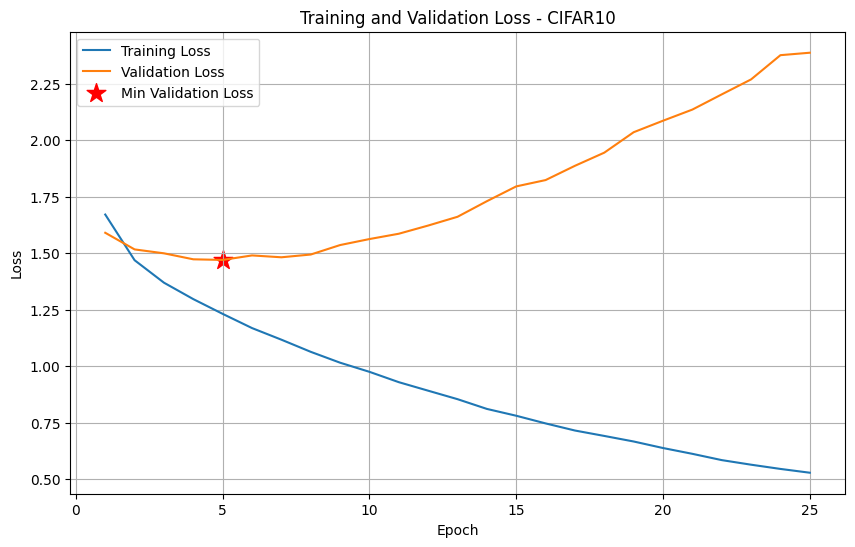

 - Accuracy: 0.4891
 - Precision: 0.4869
 - Recall: 0.4891
 - F1 Score: 0.4870


Training on AIRLINE dataset
Epoch [1/600], Loss: 0.5306, Val Loss: 0.4551
Epoch [2/600], Loss: 0.3854, Val Loss: 0.3304
Epoch [3/600], Loss: 0.2933, Val Loss: 0.2519
Epoch [4/600], Loss: 0.2429, Val Loss: 0.2037
Epoch [5/600], Loss: 0.2142, Val Loss: 0.1687
Epoch [6/600], Loss: 0.1857, Val Loss: 0.1440
Epoch [7/600], Loss: 0.1608, Val Loss: 0.1315
Epoch [8/600], Loss: 0.1434, Val Loss: 0.1253
Epoch [9/600], Loss: 0.1317, Val Loss: 0.1178
Epoch [10/600], Loss: 0.1219, Val Loss: 0.1081
Epoch [11/600], Loss: 0.1115, Val Loss: 0.0968
Epoch [12/600], Loss: 0.1010, Val Loss: 0.0845
Epoch [13/600], Loss: 0.0891, Val Loss: 0.0725
Epoch [14/600], Loss: 0.0784, Val Loss: 0.0617
Epoch [15/600], Loss: 0.0699, Val Loss: 0.0517
Epoch [16/600], Loss: 0.0614, Val Loss: 0.0373
Epoch [17/600], Loss: 0.0503, Val Loss: 0.0257
Epoch [18/600], Loss: 0.0422, Val Loss: 0.0204
Epoch [19/600], Loss: 0.0372, Val Loss: 0.0177
Epoch [

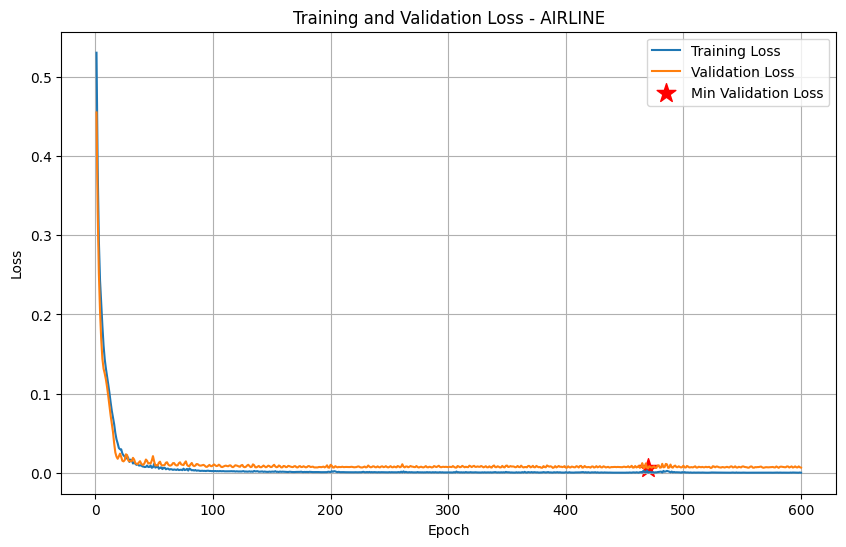

 - Mean Squared Error: 0.1222
 - R² Score: 0.6786


Training on ADULT dataset
Epoch [1/80], Loss: 0.3456, Val Loss: 0.3152
Epoch [2/80], Loss: 0.3098, Val Loss: 0.3130
Epoch [3/80], Loss: 0.3049, Val Loss: 0.3154
Epoch [4/80], Loss: 0.3008, Val Loss: 0.3158
Epoch [5/80], Loss: 0.2962, Val Loss: 0.3192
Epoch [6/80], Loss: 0.2940, Val Loss: 0.3143
Epoch [7/80], Loss: 0.2890, Val Loss: 0.3173
Epoch [8/80], Loss: 0.2861, Val Loss: 0.3192
Epoch [9/80], Loss: 0.2819, Val Loss: 0.3225
Epoch [10/80], Loss: 0.2783, Val Loss: 0.3195
Epoch [11/80], Loss: 0.2737, Val Loss: 0.3243
Epoch [12/80], Loss: 0.2687, Val Loss: 0.3406
Epoch [13/80], Loss: 0.2631, Val Loss: 0.3322
Epoch [14/80], Loss: 0.2586, Val Loss: 0.3483
Epoch [15/80], Loss: 0.2553, Val Loss: 0.3438
Epoch [16/80], Loss: 0.2501, Val Loss: 0.3407
Epoch [17/80], Loss: 0.2446, Val Loss: 0.3498
Epoch [18/80], Loss: 0.2407, Val Loss: 0.3637
Epoch [19/80], Loss: 0.2351, Val Loss: 0.3869
Epoch [20/80], Loss: 0.2315, Val Loss: 0.3865
Epoch [21/8

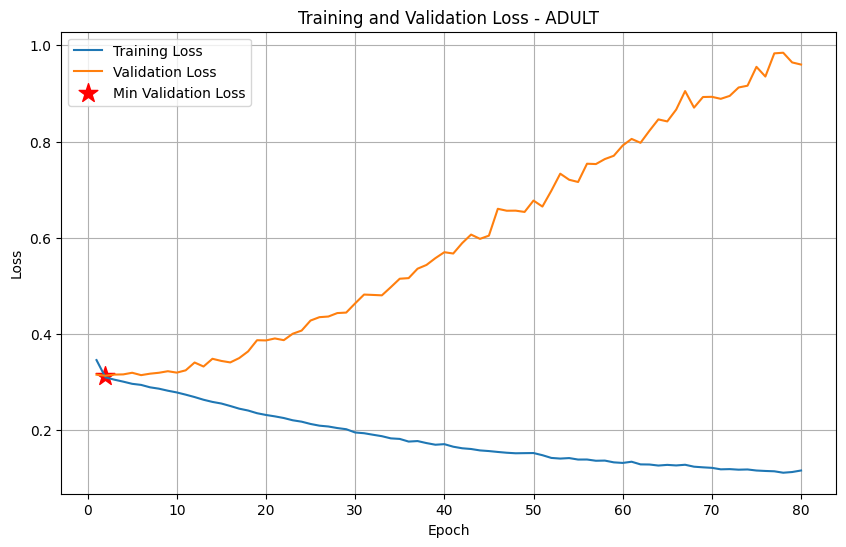

 - Accuracy: 0.8271
 - Precision: 0.8271
 - Recall: 0.8271
 - F1 Score: 0.8271


In [3]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'airline', 'adult']
EPOCHS = [25,25,600,80]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = MLP(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

# 3.1) Simple Convolutional Neural Network (CNN)

MPS is available


Training on MNIST dataset
Epoch [1/100], Loss: 1.0805, Val Loss: 0.5969
Epoch [2/100], Loss: 0.4991, Val Loss: 0.4298
Epoch [3/100], Loss: 0.3840, Val Loss: 0.3517
Epoch [4/100], Loss: 0.3236, Val Loss: 0.3095
Epoch [5/100], Loss: 0.2884, Val Loss: 0.2816
Epoch [6/100], Loss: 0.2647, Val Loss: 0.2633
Epoch [7/100], Loss: 0.2471, Val Loss: 0.2483
Epoch [8/100], Loss: 0.2335, Val Loss: 0.2375
Epoch [9/100], Loss: 0.2224, Val Loss: 0.2274
Epoch [10/100], Loss: 0.2127, Val Loss: 0.2205
Epoch [11/100], Loss: 0.2046, Val Loss: 0.2116
Epoch [12/100], Loss: 0.1976, Val Loss: 0.2068
Epoch [13/100], Loss: 0.1908, Val Loss: 0.2014
Epoch [14/100], Loss: 0.1854, Val Loss: 0.1969
Epoch [15/100], Loss: 0.1804, Val Loss: 0.1938
Epoch [16/100], Loss: 0.1760, Val Loss: 0.1873
Epoch [17/100], Loss: 0.1723, Val Loss: 0.1823
Epoch [18/100], Loss: 0.1679, Val Loss: 0.1824
Epoch [19/100], Loss: 0.1648, Val Loss: 0.1797
Epoch [20/100], Loss: 0.1615, Val Loss: 0.1786
Epoch [21/100], Loss: 0.

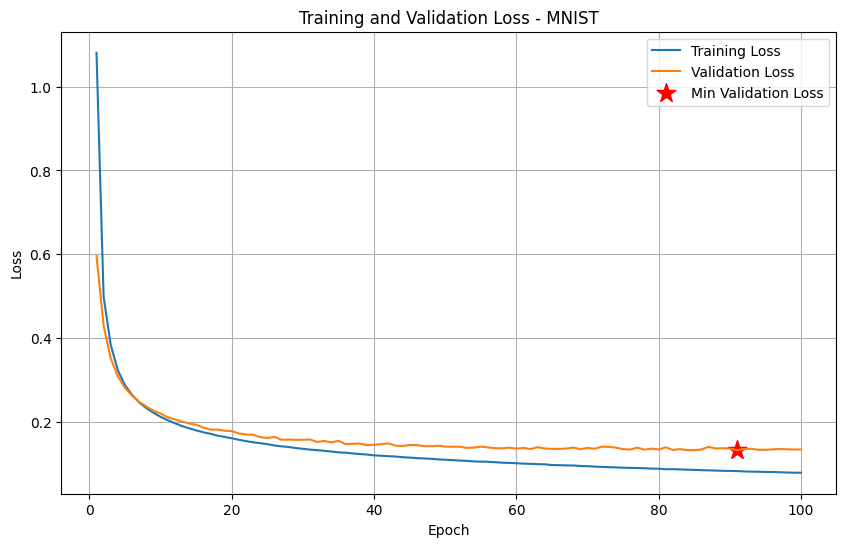

 - Accuracy: 0.9598
 - Precision: 0.9601
 - Recall: 0.9598
 - F1 Score: 0.9598


Training on CIFAR10 dataset
Epoch [1/100], Loss: 2.1023, Val Loss: 1.9870
Epoch [2/100], Loss: 1.9217, Val Loss: 1.8945
Epoch [3/100], Loss: 1.8512, Val Loss: 1.8431
Epoch [4/100], Loss: 1.8062, Val Loss: 1.8109
Epoch [5/100], Loss: 1.7700, Val Loss: 1.7815
Epoch [6/100], Loss: 1.7414, Val Loss: 1.7578
Epoch [7/100], Loss: 1.7155, Val Loss: 1.7342
Epoch [8/100], Loss: 1.6918, Val Loss: 1.7211
Epoch [9/100], Loss: 1.6742, Val Loss: 1.7036
Epoch [10/100], Loss: 1.6578, Val Loss: 1.6907
Epoch [11/100], Loss: 1.6423, Val Loss: 1.6799
Epoch [12/100], Loss: 1.6287, Val Loss: 1.6667
Epoch [13/100], Loss: 1.6173, Val Loss: 1.6568
Epoch [14/100], Loss: 1.6079, Val Loss: 1.6641
Epoch [15/100], Loss: 1.5986, Val Loss: 1.6467
Epoch [16/100], Loss: 1.5904, Val Loss: 1.6388
Epoch [17/100], Loss: 1.5825, Val Loss: 1.6472
Epoch [18/100], Loss: 1.5757, Val Loss: 1.6287
Epoch [19/100], Loss: 1.5694, Val Loss: 1.6330
Epoch [

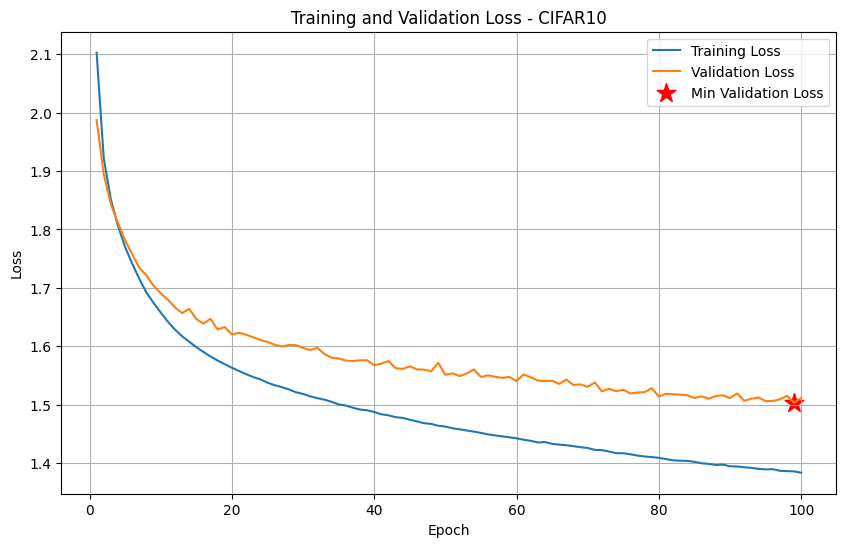

 - Accuracy: 0.4782
 - Precision: 0.4892
 - Recall: 0.4782
 - F1 Score: 0.4808


In [4]:
# Training loop
DATASETS = ['mnist', 'cifar10']
EPOCHS = [150,150]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = CNN(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

## 3.2) Convolutional Neural Network (CNN) - LeNet5

MPS is available


Training on MNIST dataset
Epoch [1/150], Loss: 1.3372, Val Loss: 0.8255
Epoch [2/150], Loss: 0.6847, Val Loss: 0.5806
Epoch [3/150], Loss: 0.5210, Val Loss: 0.4647
Epoch [4/150], Loss: 0.4307, Val Loss: 0.3966
Epoch [5/150], Loss: 0.3706, Val Loss: 0.3481
Epoch [6/150], Loss: 0.3287, Val Loss: 0.3181
Epoch [7/150], Loss: 0.2984, Val Loss: 0.2948
Epoch [8/150], Loss: 0.2749, Val Loss: 0.2702
Epoch [9/150], Loss: 0.2562, Val Loss: 0.2564
Epoch [10/150], Loss: 0.2418, Val Loss: 0.2431
Epoch [11/150], Loss: 0.2298, Val Loss: 0.2311
Epoch [12/150], Loss: 0.2197, Val Loss: 0.2299
Epoch [13/150], Loss: 0.2104, Val Loss: 0.2181
Epoch [14/150], Loss: 0.2025, Val Loss: 0.2120
Epoch [15/150], Loss: 0.1957, Val Loss: 0.2063
Epoch [16/150], Loss: 0.1891, Val Loss: 0.2000
Epoch [17/150], Loss: 0.1844, Val Loss: 0.1966
Epoch [18/150], Loss: 0.1793, Val Loss: 0.1924
Epoch [19/150], Loss: 0.1744, Val Loss: 0.1984
Epoch [20/150], Loss: 0.1707, Val Loss: 0.1936
Epoch [21/150], Loss: 0.

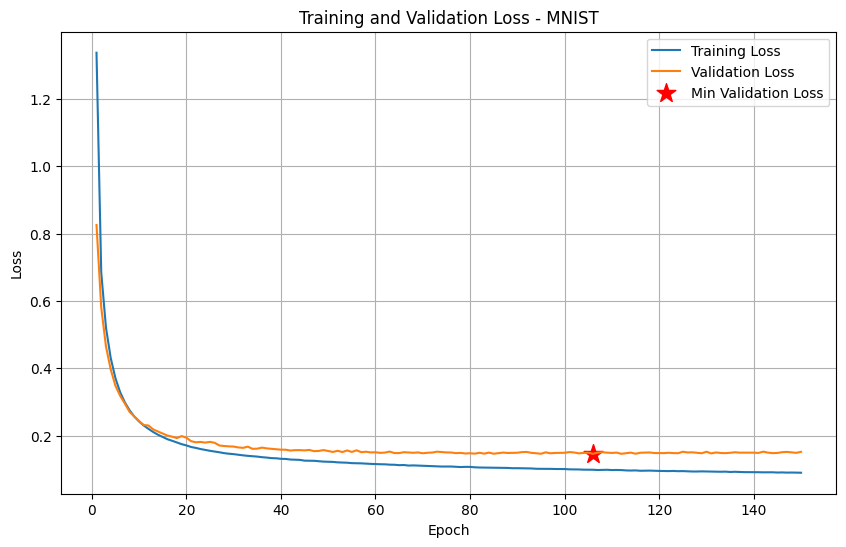

 - Accuracy: 0.9607
 - Precision: 0.9608
 - Recall: 0.9607
 - F1 Score: 0.9607


Training on CIFAR10 dataset
Epoch [1/300], Loss: 2.2102, Val Loss: 2.1582
Epoch [2/300], Loss: 2.1328, Val Loss: 2.1176
Epoch [3/300], Loss: 2.0980, Val Loss: 2.0907
Epoch [4/300], Loss: 2.0735, Val Loss: 2.0720
Epoch [5/300], Loss: 2.0439, Val Loss: 2.0348
Epoch [6/300], Loss: 2.0122, Val Loss: 2.0092
Epoch [7/300], Loss: 1.9888, Val Loss: 1.9888
Epoch [8/300], Loss: 1.9683, Val Loss: 1.9715
Epoch [9/300], Loss: 1.9508, Val Loss: 1.9591
Epoch [10/300], Loss: 1.9348, Val Loss: 1.9451
Epoch [11/300], Loss: 1.9224, Val Loss: 1.9318
Epoch [12/300], Loss: 1.9120, Val Loss: 1.9281
Epoch [13/300], Loss: 1.9032, Val Loss: 1.9177
Epoch [14/300], Loss: 1.8953, Val Loss: 1.9136
Epoch [15/300], Loss: 1.8882, Val Loss: 1.9024
Epoch [16/300], Loss: 1.8821, Val Loss: 1.8977
Epoch [17/300], Loss: 1.8762, Val Loss: 1.8976
Epoch [18/300], Loss: 1.8708, Val Loss: 1.8934
Epoch [19/300], Loss: 1.8674, Val Loss: 1.8888
Epoch [

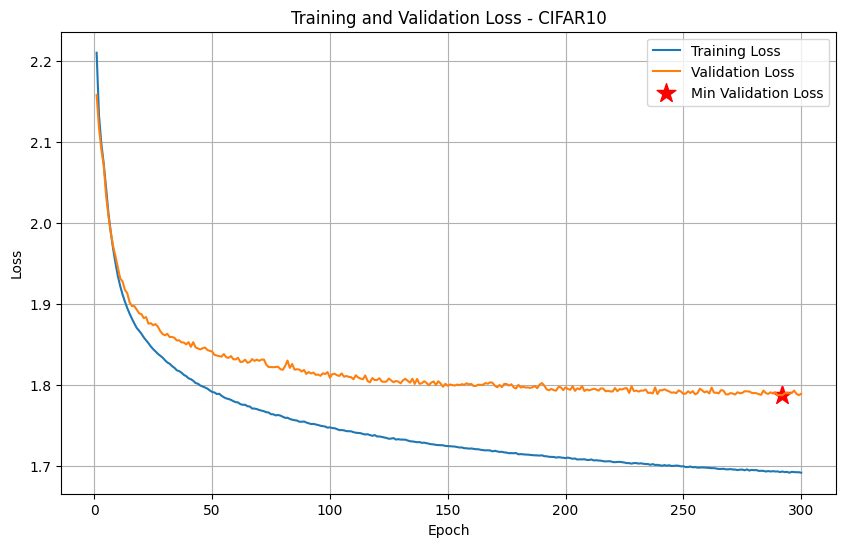

 - Accuracy: 0.3784
 - Precision: 0.4035
 - Recall: 0.3784
 - F1 Score: 0.3757


In [5]:
# Training loop
DATASETS = ['mnist', 'cifar10']
EPOCHS = [150,300]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = LeNet5Flexible(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

## 3.3) Convolutional Neural Network (CNN) - ResNet 9

MPS is available


Training on MNIST dataset
Epoch [1/25], Loss: 0.1113, Val Loss: 0.0399
Epoch [2/25], Loss: 0.0401, Val Loss: 0.0368
Epoch [3/25], Loss: 0.0268, Val Loss: 0.0419
Epoch [4/25], Loss: 0.0219, Val Loss: 0.0470
Epoch [5/25], Loss: 0.0173, Val Loss: 0.0382
Epoch [6/25], Loss: 0.0156, Val Loss: 0.0593
Epoch [7/25], Loss: 0.0133, Val Loss: 0.0371
Epoch [8/25], Loss: 0.0102, Val Loss: 0.0371
Epoch [9/25], Loss: 0.0122, Val Loss: 0.0506
Epoch [10/25], Loss: 0.0077, Val Loss: 0.0309
Epoch [11/25], Loss: 0.0098, Val Loss: 0.0340
Epoch [12/25], Loss: 0.0077, Val Loss: 0.0507
Epoch [13/25], Loss: 0.0041, Val Loss: 0.0364
Epoch [14/25], Loss: 0.0053, Val Loss: 0.0672
Epoch [15/25], Loss: 0.0072, Val Loss: 0.0350
Epoch [16/25], Loss: 0.0052, Val Loss: 0.0410
Epoch [17/25], Loss: 0.0051, Val Loss: 0.0423
Epoch [18/25], Loss: 0.0036, Val Loss: 0.0489
Epoch [19/25], Loss: 0.0042, Val Loss: 0.0379
Epoch [20/25], Loss: 0.0062, Val Loss: 0.0385
Epoch [21/25], Loss: 0.0017, Val Loss: 0.037

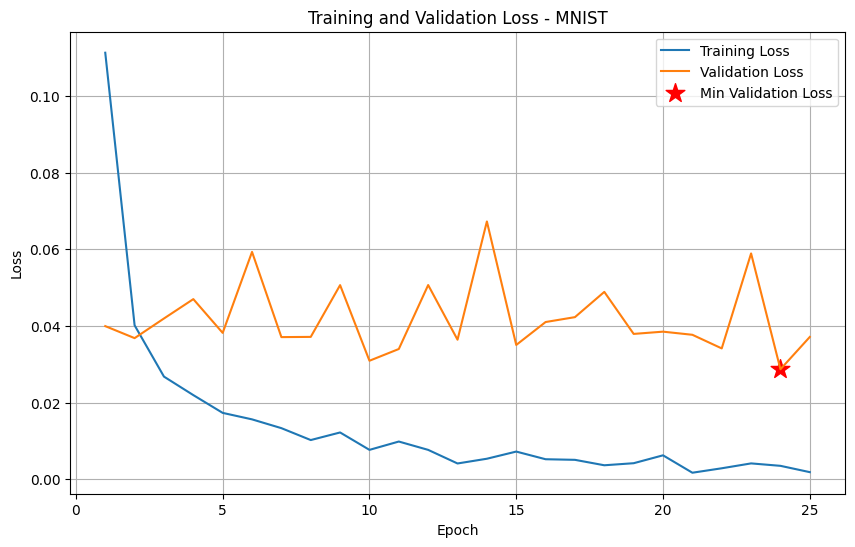

 - Accuracy: 0.9927
 - Precision: 0.9927
 - Recall: 0.9927
 - F1 Score: 0.9927


Training on CIFAR10 dataset
Epoch [1/25], Loss: 1.2871, Val Loss: 1.0318
Epoch [2/25], Loss: 0.8514, Val Loss: 0.8933
Epoch [3/25], Loss: 0.6461, Val Loss: 0.6802
Epoch [4/25], Loss: 0.4917, Val Loss: 0.6277
Epoch [5/25], Loss: 0.3562, Val Loss: 0.7547
Epoch [6/25], Loss: 0.2331, Val Loss: 0.6800
Epoch [7/25], Loss: 0.1523, Val Loss: 0.7811
Epoch [8/25], Loss: 0.1052, Val Loss: 0.7493
Epoch [9/25], Loss: 0.0817, Val Loss: 0.8139
Epoch [10/25], Loss: 0.0707, Val Loss: 0.8912
Epoch [11/25], Loss: 0.0616, Val Loss: 0.9903
Epoch [12/25], Loss: 0.0542, Val Loss: 0.9569
Epoch [13/25], Loss: 0.0523, Val Loss: 1.0663
Epoch [14/25], Loss: 0.0513, Val Loss: 0.9654
Epoch [15/25], Loss: 0.0357, Val Loss: 1.0300
Epoch [16/25], Loss: 0.0407, Val Loss: 1.0675
Epoch [17/25], Loss: 0.0401, Val Loss: 1.0115
Epoch [18/25], Loss: 0.0339, Val Loss: 1.1271
Epoch [19/25], Loss: 0.0308, Val Loss: 1.1271
Epoch [20/25], Loss: 0.034

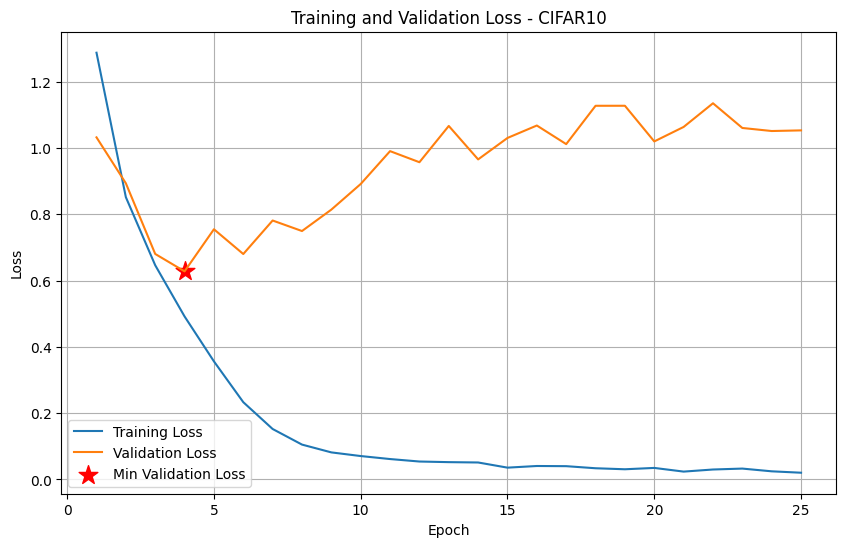

 - Accuracy: 0.8050
 - Precision: 0.8040
 - Recall: 0.8050
 - F1 Score: 0.8029


In [4]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'LSST']
EPOCHS = [30,30]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = ResNet9(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

In [9]:
# Training loop
DATASETS = [ 'LSST']
EPOCHS = [30,30]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = ResNet9(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

MPS is available


Training on LSST dataset


FileNotFoundError: [Errno 2] No such file or directory: 'datasets/LSST_train.pt'

## 4) Transformer

MPS is available


Training on MNIST dataset
Epoch [1/30], Loss: 0.2881, Val Loss: 0.1520
Epoch [2/30], Loss: 0.1399, Val Loss: 0.1315
Epoch [3/30], Loss: 0.1045, Val Loss: 0.1182
Epoch [4/30], Loss: 0.0860, Val Loss: 0.1030
Epoch [5/30], Loss: 0.0753, Val Loss: 0.0896
Epoch [6/30], Loss: 0.0673, Val Loss: 0.0791
Epoch [7/30], Loss: 0.0590, Val Loss: 0.0854
Epoch [8/30], Loss: 0.0530, Val Loss: 0.0900
Epoch [9/30], Loss: 0.0479, Val Loss: 0.0979
Epoch [10/30], Loss: 0.0455, Val Loss: 0.0839
Epoch [11/30], Loss: 0.0411, Val Loss: 0.0936
Epoch [12/30], Loss: 0.0355, Val Loss: 0.0921
Epoch [13/30], Loss: 0.0329, Val Loss: 0.0849
Epoch [14/30], Loss: 0.0325, Val Loss: 0.0881
Epoch [15/30], Loss: 0.0323, Val Loss: 0.0942
Epoch [16/30], Loss: 0.0306, Val Loss: 0.0991
Epoch [17/30], Loss: 0.0255, Val Loss: 0.0831
Epoch [18/30], Loss: 0.0238, Val Loss: 0.0942
Epoch [19/30], Loss: 0.0251, Val Loss: 0.0918
Epoch [20/30], Loss: 0.0214, Val Loss: 0.0856
Epoch [21/30], Loss: 0.0232, Val Loss: 0.096

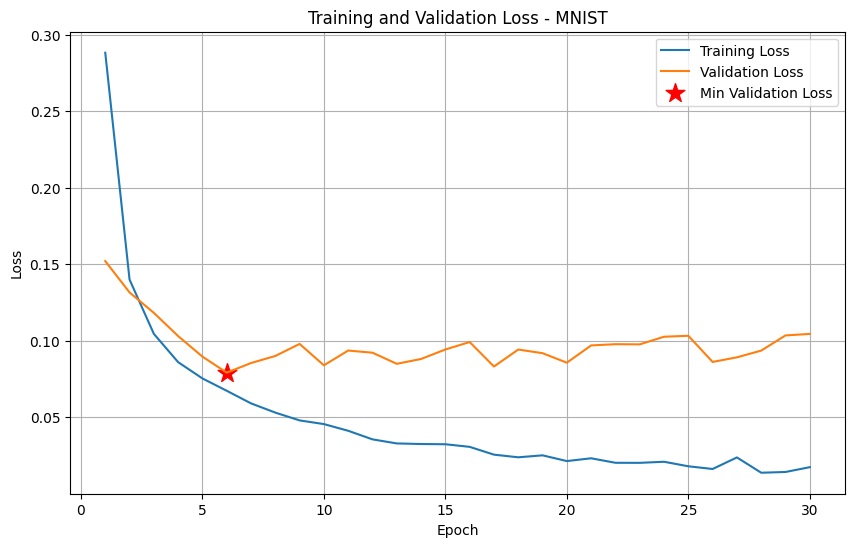

 - Accuracy: 0.9780
 - Precision: 0.9781
 - Recall: 0.9780
 - F1 Score: 0.9780


Training on CIFAR10 dataset


/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/35], Loss: 1.7931, Val Loss: 1.6670
Epoch [2/35], Loss: 1.6311, Val Loss: 1.6125
Epoch [3/35], Loss: 1.5684, Val Loss: 1.5585
Epoch [4/35], Loss: 1.5129, Val Loss: 1.5188
Epoch [5/35], Loss: 1.4697, Val Loss: 1.4732
Epoch [6/35], Loss: 1.4504, Val Loss: 1.5310
Epoch [7/35], Loss: 1.4278, Val Loss: 1.4920
Epoch [8/35], Loss: 1.3896, Val Loss: 1.4489
Epoch [9/35], Loss: 1.3668, Val Loss: 1.4532
Epoch [10/35], Loss: 1.3344, Val Loss: 1.4184
Epoch [11/35], Loss: 1.2972, Val Loss: 1.3766
Epoch [12/35], Loss: 1.2751, Val Loss: 1.4176
Epoch [13/35], Loss: 1.2489, Val Loss: 1.3998
Epoch [14/35], Loss: 1.2376, Val Loss: 1.3821
Epoch [15/35], Loss: 1.2073, Val Loss: 1.3873
Epoch [16/35], Loss: 1.2034, Val Loss: 1.3816
Epoch [17/35], Loss: 1.1666, Val Loss: 1.3685
Epoch [18/35], Loss: 1.1318, Val Loss: 1.3675
Epoch [19/35], Loss: 1.1138, Val Loss: 1.3712
Epoch [20/35], Loss: 1.1038, Val Loss: 1.3711
Epoch [21/35], Loss: 1.0684, Val Loss: 1.3834
Epoch [22/35], Loss: 1.0623, Val Loss: 1.39

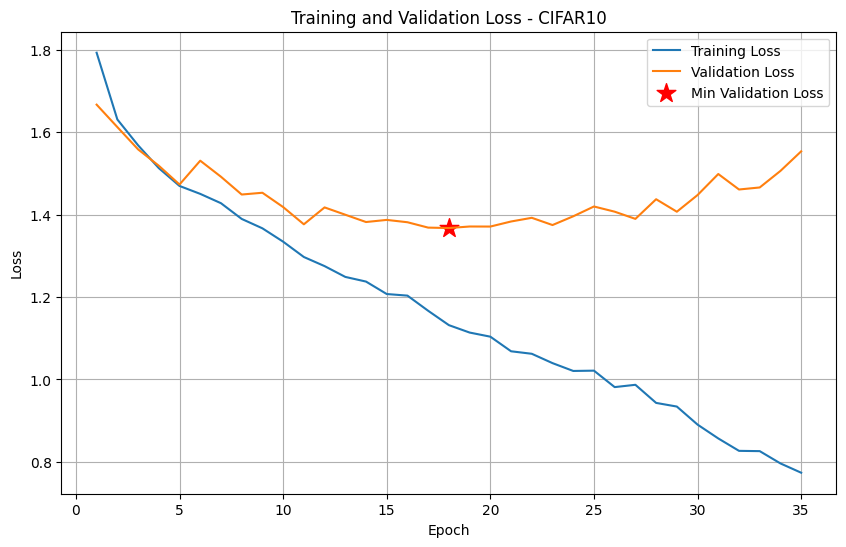

 - Accuracy: 0.5389
 - Precision: 0.5408
 - Recall: 0.5389
 - F1 Score: 0.5379


Training on AIRLINE dataset
Epoch [1/600], Loss: 1.5663, Val Loss: 1.4602
Epoch [2/600], Loss: 1.5194, Val Loss: 0.3437
Epoch [3/600], Loss: 0.4146, Val Loss: 0.2626
Epoch [4/600], Loss: 0.1877, Val Loss: 0.8796
Epoch [5/600], Loss: 0.4168, Val Loss: 1.1316
Epoch [6/600], Loss: 0.5325, Val Loss: 0.8531
Epoch [7/600], Loss: 0.3995, Val Loss: 0.5827


/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [8/600], Loss: 0.3055, Val Loss: 0.4313
Epoch [9/600], Loss: 0.3041, Val Loss: 0.3525
Epoch [10/600], Loss: 0.2794, Val Loss: 0.3189
Epoch [11/600], Loss: 0.2366, Val Loss: 0.3024
Epoch [12/600], Loss: 0.1809, Val Loss: 0.2806
Epoch [13/600], Loss: 0.1485, Val Loss: 0.2456
Epoch [14/600], Loss: 0.1082, Val Loss: 0.1887
Epoch [15/600], Loss: 0.1001, Val Loss: 0.1161
Epoch [16/600], Loss: 0.0896, Val Loss: 0.0752
Epoch [17/600], Loss: 0.0921, Val Loss: 0.0727
Epoch [18/600], Loss: 0.0956, Val Loss: 0.0755
Epoch [19/600], Loss: 0.0975, Val Loss: 0.0913
Epoch [20/600], Loss: 0.0758, Val Loss: 0.0671
Epoch [21/600], Loss: 0.0589, Val Loss: 0.0451
Epoch [22/600], Loss: 0.0543, Val Loss: 0.0418
Epoch [23/600], Loss: 0.0485, Val Loss: 0.0443
Epoch [24/600], Loss: 0.0454, Val Loss: 0.0441
Epoch [25/600], Loss: 0.0415, Val Loss: 0.0439
Epoch [26/600], Loss: 0.0465, Val Loss: 0.0387
Epoch [27/600], Loss: 0.0351, Val Loss: 0.0303
Epoch [28/600], Loss: 0.0338, Val Loss: 0.0435
Epoch [29/600],

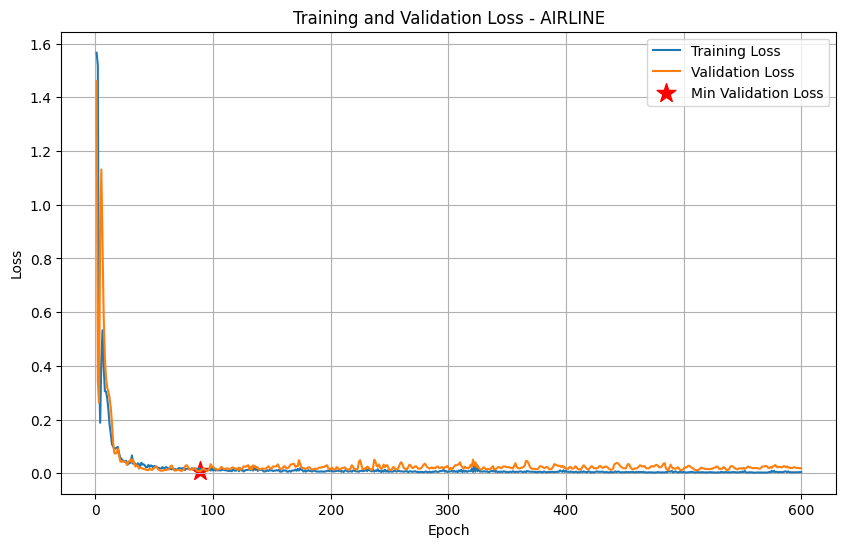

 - Mean Squared Error: 0.2454
 - R² Score: 0.3544


Training on ADULT dataset


/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/80], Loss: 0.3414, Val Loss: 0.3303
Epoch [2/80], Loss: 0.3171, Val Loss: 0.3150
Epoch [3/80], Loss: 0.3103, Val Loss: 0.3191
Epoch [4/80], Loss: 0.3055, Val Loss: 0.3197
Epoch [5/80], Loss: 0.3019, Val Loss: 0.3168
Epoch [6/80], Loss: 0.2981, Val Loss: 0.3161
Epoch [7/80], Loss: 0.2983, Val Loss: 0.3173
Epoch [8/80], Loss: 0.2955, Val Loss: 0.3171
Epoch [9/80], Loss: 0.2918, Val Loss: 0.3237
Epoch [10/80], Loss: 0.2898, Val Loss: 0.3136
Epoch [11/80], Loss: 0.2895, Val Loss: 0.3232
Epoch [12/80], Loss: 0.2853, Val Loss: 0.3274
Epoch [13/80], Loss: 0.2835, Val Loss: 0.3163
Epoch [14/80], Loss: 0.2831, Val Loss: 0.3204
Epoch [15/80], Loss: 0.2805, Val Loss: 0.3142
Epoch [16/80], Loss: 0.2778, Val Loss: 0.3488
Epoch [17/80], Loss: 0.2776, Val Loss: 0.3332
Epoch [18/80], Loss: 0.2745, Val Loss: 0.3257
Epoch [19/80], Loss: 0.2693, Val Loss: 0.3384
Epoch [20/80], Loss: 0.2694, Val Loss: 0.3378
Epoch [21/80], Loss: 0.2667, Val Loss: 0.3543
Epoch [22/80], Loss: 0.2612, Val Loss: 0.35

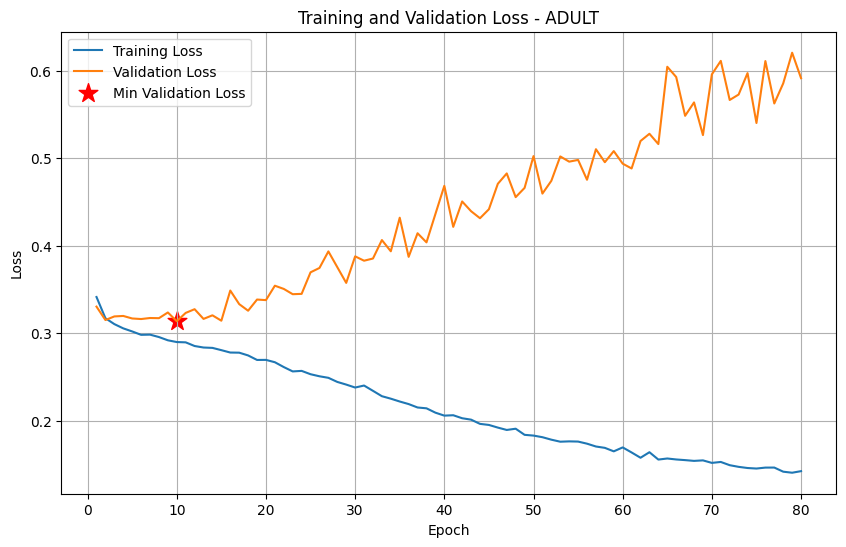

 - Accuracy: 0.8328
 - Precision: 0.8288
 - Recall: 0.8328
 - F1 Score: 0.8305


In [5]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'airline', 'adult']
EPOCHS = [30,35,600,80]
BATCH_SIZE = 64
LEARNING_RATE = 0.001
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    model = TransformerModelFlexible(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

In [43]:
# Initialize dataset loader
ucr_loader = UCR_UEA_datasets()

# Load a specific dataset
X_train, y_train, X_test, y_test = ucr_loader.load_dataset("LSST") # typucal accuracy 80% to 90%.
print(X_test.shape) # batch, time, dim

mask = y_test != '92'
X_test = X_test[mask]
y_test = y_test[mask]
mask = y_train != '92'
X_train = X_train[mask]
y_train = y_train[mask]
print(X_test.shape)

mask = y_test != '95'
X_test = X_test[mask]
y_test = y_test[mask]
mask = y_train != '95'
X_train = X_train[mask]
y_train = y_train[mask]
print(X_test.shape)

(2466, 36, 6)
(2389, 36, 6)
(2337, 36, 6)


In [24]:
# Initialize dataset loader
from tslearn.datasets import UCR_UEA_datasets

ucr_loader = UCR_UEA_datasets()

# Load a specific dataset
X_train, y_train, X_test, y_test = ucr_loader.load_dataset("Epilepsy")
X_train.shape

(137, 206, 3)

MPS is available


Training on LSST dataset


/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/600], Loss: 2.1727, Val Loss: 2.0115
Epoch [2/600], Loss: 2.0582, Val Loss: 2.0277
Epoch [3/600], Loss: 2.0099, Val Loss: 2.6645
Epoch [4/600], Loss: 1.9333, Val Loss: 1.7770
Epoch [5/600], Loss: 1.8991, Val Loss: 1.5230
Epoch [6/600], Loss: 1.8530, Val Loss: 1.9826
Epoch [7/600], Loss: 1.7873, Val Loss: 1.6758
Epoch [8/600], Loss: 1.7306, Val Loss: 1.6655
Epoch [9/600], Loss: 1.6950, Val Loss: 1.6615
Epoch [10/600], Loss: 1.6609, Val Loss: 1.6979
Epoch [11/600], Loss: 1.6261, Val Loss: 1.7195
Epoch [12/600], Loss: 1.6305, Val Loss: 1.7036
Epoch [13/600], Loss: 1.5962, Val Loss: 1.7423
Epoch [14/600], Loss: 1.5757, Val Loss: 1.7833
Epoch [15/600], Loss: 1.5436, Val Loss: 1.6594
Epoch [16/600], Loss: 1.5198, Val Loss: 2.0286
Epoch [17/600], Loss: 1.5151, Val Loss: 1.6665
Epoch [18/600], Loss: 1.4901, Val Loss: 1.7962
Epoch [19/600], Loss: 1.4972, Val Loss: 1.7600
Epoch [20/600], Loss: 1.4908, Val Loss: 1.6750
Epoch [21/600], Loss: 1.4821, Val Loss: 1.8516
Epoch [22/600], Loss: 

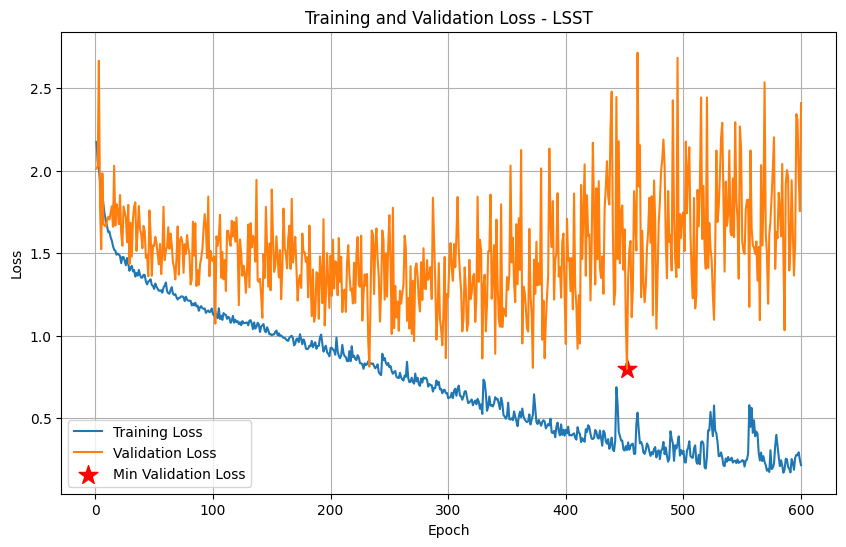

 - Accuracy: 0.6371
 - Precision: 0.6238
 - Recall: 0.6371
 - F1 Score: 0.6257


In [17]:
from torch.utils.data import Subset
from tslearn.datasets import UCR_UEA_datasets
from torch.utils.data import DataLoader, random_split
from torch import nn, optim

# Initialize dataset loader
ucr_loader = UCR_UEA_datasets()

# Load a specific dataset
X_train, y_train, X_test, y_test = ucr_loader.load_dataset("LSST") 

mask = y_test != '92'
X_test = X_test[mask]
y_test = y_test[mask]
mask = y_train != '92'
X_train = X_train[mask]
y_train = y_train[mask]

mask = y_test != '95'
X_test = X_test[mask]
y_test = y_test[mask]
mask = y_train != '95'
X_train = X_train[mask]
y_train = y_train[mask]

config = {
    'mnist': {
        'task_type': 'classification',
        'num_classes': 10,
        'input_dim': 28 * 28,
        'input_channels': 1
    },
    'cifar10': {
        'task_type': 'classification',
        'num_classes': 10,
        'input_dim': 32 * 32 * 3,
        'input_channels': 3
    },
    'airline': {
        'task_type': 'regression',
        'num_classes': None,
        'input_dim': 30,
    },
    'adult': {
        'task_type': 'classification',
        'num_classes': 2,
        'input_dim': 105,
    },
    'LSST': {
        'task_type': 'classification',
        'num_classes': 12,
        'input_dim': 36 * 6,
        'input_channels': 1
    }
}

class MLP(nn.Module):
    def __init__(self, dataset_name, hidden_dim=128):
        """
        Initializes the MLP model.

        Args:
            input_dim (int): The number of input features.
            hidden_dim (int): The number of neurons in the hidden layers.
            task_type (str): The type of task ('regression' or 'classification').
            output_dim (int, optional): The number of output neurons. For regression, this is typically 1.
                                        For classification, this corresponds to the number of classes.
        """
        super(MLP, self).__init__()
        
        self.task_type = config[dataset_name]['task_type']
        input_dim = config[dataset_name]['input_dim']
        output_dim = config[dataset_name]['num_classes']
        
        self.criterion = nn.MSELoss() if self.task_type == 'regression' else nn.CrossEntropyLoss()
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        
        if self.task_type == 'regression':
            self.fc3 = nn.Linear(hidden_dim, 1)  # Single output for regression
        elif self.task_type == 'classification':
            if output_dim is None:
                raise ValueError("output_dim must be specified for classification tasks.")
            self.fc3 = nn.Linear(hidden_dim, output_dim)  # Output layer for classification
        else:
            raise ValueError("Invalid task_type. Choose either 'regression' or 'classification'.")

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        
        return x
    
# transformer model with 'correct' input dimension
class TransformerModelFlexible(nn.Module):
    def __init__(self, dataset_name, num_heads=2, num_layers=2, hidden_dim=64):
        super(TransformerModelFlexible, self).__init__()

        input_dim = 6  # Since your time series has 1 feature
        # sequence_length = 30  # Fixed sequence length for the time series data
        output_dim = config[dataset_name]['num_classes']

        self.criterion = nn.CrossEntropyLoss() if config[dataset_name]['task_type'] == 'classification' else nn.MSELoss()
        self.task_type = config[dataset_name]['task_type']
        self.sequence_length = config[dataset_name]['input_dim']

        # Transformer Components
        self.embedding = nn.Linear(input_dim, hidden_dim)  # Input_dim=1 -> hidden_dim=64
        self.pos_encoder = nn.Parameter(torch.zeros(1, self.sequence_length, hidden_dim))  # Positional encoding for sequence length 30
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        if self.task_type == 'regression':
            self.fc = nn.Linear(hidden_dim, 1)  # Single output for regression
        elif self.task_type == 'classification':
            if output_dim is None:
                raise ValueError("output_dim must be specified for classification tasks.")
            self.fc = nn.Linear(hidden_dim, output_dim)  # Output layer for classification
        else:
            raise ValueError("Invalid task_type. Choose either 'regression' or 'classification'.")

    def forward(self, x):
        x = self.embedding(x)  # Shape: (batch_size, sequence_length, hidden_dim)
        x = x + self.pos_encoder[:, :x.size(1), :]  # Add positional encoding
        x = self.transformer(x)  # Shape: (batch_size, sequence_length, hidden_dim)
        x = x.mean(dim=1)  # Global average pooling to get (batch_size, hidden_dim)
        x = self.fc(x)  # Shape: (batch_size, output_dim) for classification or (batch_size, 1) for regression
        
        return x
    
def preprocessing_input(x, labels, device='cpu', model='MLP'):
    """
    Preprocesses input data based on the model type and input dimensionality.

    Args:
        x (torch.Tensor): Input data tensor.
        labels (torch.Tensor): Target labels tensor.
        device (str): Device to move tensors to ('cpu' or 'cuda').
        model (nn.Module): The model instance.

    Returns:
        tuple: Processed input tensor and labels tensor moved to the specified device.
    """
    model_name = model.__class__.__name__

    if model_name in ['CNN', 'ResNet9', 'LeNet5Flexible']:
        # CNNs and similar models expect 4D input tensors with shape (batch_size, channels, height, width)
        if x.dim() == 4:
            return x.to(device), labels.to(device)
        elif x.dim() == 3:  # Handle time series data by adding a channel dimension
            return x.unsqueeze(1).to(device), labels.to(device)
        elif x.dim() == 2:  # Handle tabular data by adding channel, height, and width dimensions
            return x.unsqueeze(1).unsqueeze(2).unsqueeze(3).to(device), labels.to(device)
        else:
            raise ValueError("For CNN-based models, expected a 4D tensor with shape (batch_size, channels, height, width).")
    
    elif model_name in ['MLP', 'LinearModel']:
        # MLPs and linear models expect 2D input tensors
        if x.dim() == 4:  # Flatten image data
            return x.view(x.size(0), -1).to(device), labels.to(device)
        elif x.dim() == 3:  # Time series data
            return x.view(x.size(0), x.size(1) * x.size(2)).to(device), labels.to(device)
        elif x.dim() == 2:  # Tabular data
            return x.to(device), labels.to(device)
        else:
            raise ValueError("For MLP/LinearModel, expected either 4D tensor (batch_size, channels, height, width) or 2D tensor (batch_size, num_features).")
    
    elif model_name in ['TransformerModelFlexible']:
        # Transformers expect 3D input tensors with shape (batch_size, sequence_length, input_dim)
        if x.dim() == 4:  # Handle image data by flattening spatial dimensions
            batch_size, channels, height, width = x.size()
            x_flat = x.view(batch_size, channels * height * width).unsqueeze(2)  # Treat flattened image as a sequence
            return x_flat.to(device), labels.to(device)
        elif x.dim() == 3: # Time series data
            return x.to(device), labels.to(device)
        elif x.dim() == 2:  # Tabular data
            return x.unsqueeze(2).to(device), labels.to(device)  # Treat tabular data as a sequence of length 1
        else:
            raise ValueError("For TransformerModelFlexible, expected a 3D tensor (batch_size, sequence_length, input_dim), 4D tensor (batch_size, channels, height, width), or 2D tensor (batch_size, num_features).")
    
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

# Training loop
DATASETS = ['LSST']
EPOCHS = [600]
BATCH_SIZE = 64
LEARNING_RATE = 0.0005
DEVICE = check_gpu()


performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    # train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    # test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    if dataset == 'airline':
        train_size = int(0.8 * len(train_dataset))
        val_size = len(train_dataset) - train_size

        # Create indices for training and validation sets
        train_indices = list(range(0, train_size))
        val_indices = list(range(train_size, len(train_dataset)))

        # Create the training and validation subsets
        train_subset = Subset(train_dataset, train_indices)
        val_subset = Subset(train_dataset, val_indices)

        # Create DataLoader
        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    else: 
    
        # train_size = int(0.8 * len(train_dataset))
        # val_size = len(train_dataset) - train_size
        # train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
        train_size = int(0.8 * len(X_train))
        val_size = len(X_train) - train_size
        X_train, y_train, X_val, y_val = X_train[:train_size], y_train[:train_size], X_train[train_size:], y_train[train_size:]
        
        from sklearn.preprocessing import LabelEncoder
        import torch
        from torch.utils.data import DataLoader, TensorDataset

        # Step 1: Encode the string labels
        label_encoder = LabelEncoder()

        # Assuming y_train, y_val, y_test are originally string labels
        y_train_encoded = label_encoder.fit_transform(y_train)
        y_val_encoded = label_encoder.transform(y_val)
        y_test_encoded = label_encoder.transform(y_test)

        # Step 2: Convert to PyTorch tensors
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)  # Convert X_train to float tensor
        y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)  # Convert labels to long tensor

        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)

        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

        # Step 3: Create TensorDataset
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        
        # Create DataLoader
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


    # Model, criterion, and optimizer
    model = TransformerModelFlexible(dataset_name=dataset, num_heads=2, num_layers=2, hidden_dim=64).to(DEVICE)
    # model = ResNet9(dataset_name=dataset).to(DEVICE)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    best_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

In [15]:
model = TransformerModelFlexible(dataset_name=dataset, num_heads=2, num_layers=3, hidden_dim=64).to(DEVICE)


# calculate number of parameters
def count_parameters(model):
    x = sum(p.numel() for p in model.parameters() if p.requires_grad) 
    print(f'The model has {x:,} trainable parameters')
    return x

x = count_parameters(model)

The model has 858,508 trainable parameters


/Users/dariofenoglio/miniforge3/envs/eris/lib/python3.10/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


## 6) Long-Short Time Model (LSTM)

MPS is available


Training on AIRLINE dataset
Epoch [1/1000], Loss: 0.4996, Val Loss: 0.4955
Epoch [2/1000], Loss: 0.4955, Val Loss: 0.4916
Epoch [3/1000], Loss: 0.4916, Val Loss: 0.4879
Epoch [4/1000], Loss: 0.4879, Val Loss: 0.4840
Epoch [5/1000], Loss: 0.4840, Val Loss: 0.4801
Epoch [6/1000], Loss: 0.4801, Val Loss: 0.4761
Epoch [7/1000], Loss: 0.4761, Val Loss: 0.4721
Epoch [8/1000], Loss: 0.4721, Val Loss: 0.4681
Epoch [9/1000], Loss: 0.4681, Val Loss: 0.4641
Epoch [10/1000], Loss: 0.4641, Val Loss: 0.4602
Epoch [11/1000], Loss: 0.4602, Val Loss: 0.4562
Epoch [12/1000], Loss: 0.4562, Val Loss: 0.4522
Epoch [13/1000], Loss: 0.4522, Val Loss: 0.4481
Epoch [14/1000], Loss: 0.4481, Val Loss: 0.4439
Epoch [15/1000], Loss: 0.4439, Val Loss: 0.4396
Epoch [16/1000], Loss: 0.4396, Val Loss: 0.4351
Epoch [17/1000], Loss: 0.4351, Val Loss: 0.4303
Epoch [18/1000], Loss: 0.4303, Val Loss: 0.4253
Epoch [19/1000], Loss: 0.4253, Val Loss: 0.4199
Epoch [20/1000], Loss: 0.4199, Val Loss: 0.4141
Ep

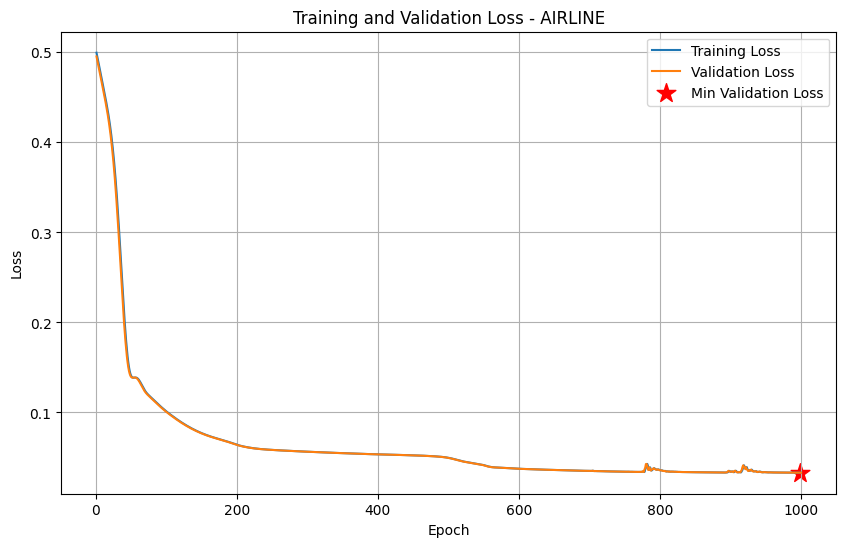

 - Mean Squared Error: 0.5416
 - R² Score: -0.4248


In [58]:
class MultiLayerLSTM(nn.Module):
    def __init__(self, dataset_name, hidden_dim=64, num_layers=1):
        super(MultiLayerLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        input_dim = 1  # Since your time series has 1 feature
        output_dim = config[dataset_name]['num_classes']

        self.criterion = nn.CrossEntropyLoss() if config[dataset_name]['task_type'] == 'classification' else nn.MSELoss()
        self.task_type = config[dataset_name]['task_type']

        # LSTM Layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        if self.task_type == 'regression':
            self.fc = nn.Linear(hidden_dim, 1)  # Single output for regression
        elif self.task_type == 'classification':
            if output_dim is None:
                raise ValueError("output_dim must be specified for classification tasks.")
            self.fc = nn.Linear(hidden_dim, output_dim)  # Output layer for classification
        else:
            raise ValueError("Invalid task_type. Choose either 'regression' or 'classification'.")
        
    def forward(self, x):
        # Set initial hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

def preprocessing_input(x, labels, device='cpu', model='MLP'):
    """
    Preprocesses input data based on the model type and input dimensionality.

    Args:
        x (torch.Tensor): Input data tensor.
        labels (torch.Tensor): Target labels tensor.
        device (str): Device to move tensors to ('cpu' or 'cuda').
        model (nn.Module): The model instance.

    Returns:
        tuple: Processed input tensor and labels tensor moved to the specified device.
    """
    model_name = model.__class__.__name__

    if model_name in ['CNN', 'ResNet9', 'LeNet5Flexible']:
        # CNNs and similar models expect 4D input tensors with shape (batch_size, channels, height, width)
        if x.dim() == 4:
            return x.to(device), labels.to(device)
        else:
            raise ValueError("For CNN-based models, expected a 4D tensor with shape (batch_size, channels, height, width).")
    
    elif model_name in ['MLP', 'LinearModel']:
        # MLPs and linear models expect 2D input tensors
        if x.dim() == 4:  # Flatten image data
            return x.view(x.size(0), -1).to(device), labels.to(device)
        elif x.dim() == 2:  # Tabular data
            return x.to(device), labels.to(device)
        else:
            raise ValueError("For MLP/LinearModel, expected either 4D tensor (batch_size, channels, height, width) or 2D tensor (batch_size, num_features).")
    
    elif model_name in ['TransformerModelFlexible', 'MultiLayerLSTM']:
        # Transformers expect 3D input tensors with shape (batch_size, sequence_length, input_dim)
        if x.dim() == 3:
            return x.to(device), labels.to(device)
        elif x.dim() == 4:  # Handle image data by flattening spatial dimensions
            batch_size, channels, height, width = x.size()
            x_flat = x.view(batch_size, channels * height * width).unsqueeze(2)  # Treat flattened image as a sequence
            return x_flat.to(device), labels.to(device)
        elif x.dim() == 2:  # Tabular data
            return x.unsqueeze(2).to(device), labels.to(device)  # Treat tabular data as a sequence of length 1
        else:
            raise ValueError("For TransformerModelFlexible, expected a 3D tensor (batch_size, sequence_length, input_dim), 4D tensor (batch_size, channels, height, width), or 2D tensor (batch_size, num_features).")
    
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

from torch.autograd import Variable

# class MultiLayerLSTM(nn.Module):

#     def __init__(self, num_classes, input_size, hidden_size, num_layers):
#         super(MultiLayerLSTM, self).__init__()
        
#         dataset_name = 'airline'
        
#         self.num_classes = num_classes
#         self.num_layers = num_layers
#         self.input_size = input_size
#         self.hidden_size = hidden_size
#         self.seq_length = 30
        
#         self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
#                             num_layers=num_layers, batch_first=True)
        
#         self.fc = nn.Linear(hidden_size, num_classes)
        
#         input_dim = 1  # Since your time series has 1 feature
#         output_dim = config[dataset_name]['num_classes']

#         self.criterion = nn.CrossEntropyLoss() if config[dataset_name]['task_type'] == 'classification' else nn.MSELoss()
#         self.task_type = config[dataset_name]['task_type']

#     def forward(self, x):
#         h_0 = Variable(torch.zeros(
#             self.num_layers, x.size(0), self.hidden_size)).to(x.device)
#         c_0 = Variable(torch.zeros(
#             self.num_layers, x.size(0), self.hidden_size)).to(x.device)
        
#         # Propagate input through LSTM
#         ula, (h_out, _) = self.lstm(x, (h_0, c_0))
#         h_out = h_out.view(-1, self.hidden_size)
#         out = self.fc(h_out)
        
        # return out
        
def train_model(model, Xtrain, Ytrain, Xval, Yval, criterion, optimizer, num_epochs=10, device='cpu'):
    best_model = None
    best_val_loss = float('inf')
    metrics = {'loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        model.train()
        
        # for images, labels in train_loader:
        # images, labels = preprocessing_input(Xtrain, Ytrain, device, model)  # Flatten the image according to its dimensionality
        # images, labels = Xtrain, Ytrain
            
        # if model.task_type == 'regression':
        #     labels = labels.float().view(-1, 1)  # Convert labels to float for regression
        # elif model.task_type == 'classification':
        #     labels = labels.long()  # Ensure labels are in long format for classification
        
        # Zero the parameter gradients
        optimizer.zero_grad()
            
        # Forward pass
        outputs = model(Xtrain)
        loss = criterion(outputs, Ytrain)
            
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
                    
        # Calculate average training loss
        metrics['loss'].append(loss.item())
        
        # Evaluate on the validation set
        # val_loss = evaluate(model, val_loader, criterion, device=device)
        with torch.no_grad():
            model.eval()
            # val_images, val_labels = preprocessing_input(Xval, Yval, device, model)
            
            # if model.task_type == 'regression':
            #     val_labels = val_labels.float().view(-1, 1)
            # elif model.task_type == 'classification':
            #     val_labels = val_labels.long()
                
            val_outputs = model(Xval)
            val_loss = criterion(val_outputs, Yval).item()
            
        metrics['val_loss'].append(val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}')
        
        # Check if this is the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())  # Save the best model
    
    # Load the best model for return
    model.load_state_dict(best_model)
    
    return model, metrics

# Training loop
DATASETS = ['airline']
EPOCHS = [1000]
BATCH_SIZE = 128
LEARNING_RATE = 0.01
DEVICE = check_gpu()

performance = {}
for n, dataset in enumerate(DATASETS):
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt', weights_only=False)
    test_dataset = torch.load(f'datasets/{dataset}_test.pt', weights_only=False)

    # Split train dataset into train and validation sets
    if dataset == 'airline':
        train_size = int(0.8 * len(train_dataset))
        val_size = len(train_dataset) - train_size

        # Create indices for training and validation sets
        train_indices = list(range(0, train_size))
        val_indices = list(range(train_size, len(train_dataset)))

        # Create the training and validation subsets
        train_subset = Subset(train_dataset, train_indices)
        val_subset = Subset(train_dataset, val_indices)
    else: 
        train_size = int(0.8 * len(train_dataset))
        val_size = len(train_dataset) - train_size
        train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
    
    trainX, trainY = train_subset.dataset.tensors
    valX, valY = val_subset.dataset.tensors
    testX, testY = test_dataset.tensors

    # Create DataLoader
    # train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    # val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    # test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    # model = MultiLayerLSTM(dataset_name=dataset).to(DEVICE)
    # criterion = model.criterion
    
    input_size = 1
    hidden_size = 2
    num_layers = 1
    num_classes = 1
    # model = MultiLayerLSTM(num_classes, input_size, hidden_size, num_layers).to(DEVICE)
    model = MultiLayerLSTM(dataset, hidden_size, num_layers).to(DEVICE)
    criterion = nn.MSELoss()
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    trainX = trainX.to(DEVICE)
    trainY = trainY.to(DEVICE)
    valX = valX.to(DEVICE)
    valY = valY.to(DEVICE)
    best_model, metrics = train_model(model, trainX, trainY, valX, valY, criterion, optimizer, num_epochs=EPOCHS[n], device=DEVICE)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    if model.task_type == 'regression':
        mse, r2 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'mse': mse, 'r2': r2}
    elif model.task_type == 'classification':
        accuracy, precision, recall, f1 = evaluate_test(best_model, test_loader, device=DEVICE)
        performance[dataset] = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
if not os.path.exists('checkpoints'):
    os.makedirs('checkpoints')
torch.save(performance, f"metrics/performance_{model.__class__.__name__}.pt")
torch.save(metrics, f"metrics/training_metrics_{model.__class__.__name__}.pt")
torch.save(best_model, f"checkpoints/CL_model_{model.__class__.__name__}.pt")

In [18]:
train_dataset = torch.load(f'datasets/{"lsst"}_train.pt', weights_only=False)
train_dataset.tensors[0].shape


torch.Size([2331, 36, 6])

In [103]:
train_dataset = torch.load(f'datasets/{"airline"}_train.pt', weights_only=False)
test_dataset = torch.load(f'datasets/{"airline"}_test.pt', weights_only=False)
# take the features and labels from the datasets
trainX, trainY = train_dataset.tensors
# val_size = int(0.8 * len(train_dataset))
# valX, valY = trainX[val_size:], trainY[val_size:]
# trainX, trainY = trainX[:val_size], trainY[:val_size]
testX, testY = test_dataset.tensors

num_epochs = 1000
learning_rate = 0.01

input_size = 1
hidden_size = 4
num_layers = 1
num_classes = 1

class LSTM(nn.Module):

    def __init__(self, num_classes, input_size, hidden_size, num_layers):
        super(LSTM, self).__init__()
        
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.seq_length = 30
        
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h_0 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_size))
        c_0 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_size))
        
        # Propagate input through LSTM
        ula, (h_out, _) = self.lstm(x, (h_0, c_0))
        h_out = h_out.view(-1, self.hidden_size)
        out = self.fc(h_out)
        
        return out
class MultiLayerLSTM(nn.Module):
    def __init__(self, dataset_name, hidden_dim=2, num_layers=1):
        super(MultiLayerLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        input_dim = 1  # Since your time series has 1 feature
        output_dim = config[dataset_name]['num_classes']

        self.criterion = nn.CrossEntropyLoss() if config[dataset_name]['task_type'] == 'classification' else nn.MSELoss()
        self.task_type = config[dataset_name]['task_type']

        # LSTM Layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        if self.task_type == 'regression':
            self.fc = nn.Linear(hidden_dim, 1)  # Single output for regression
        elif self.task_type == 'classification':
            if output_dim is None:
                raise ValueError("output_dim must be specified for classification tasks.")
            self.fc = nn.Linear(hidden_dim, output_dim)  # Output layer for classification
        else:
            raise ValueError("Invalid task_type. Choose either 'regression' or 'classification'.")

    def forward(self, x):
        # Set initial hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out
    
lstm = LSTM(num_classes, input_size, hidden_size, num_layers)
# lstm = MultiLayerLSTM('airline', hidden_size, num_layers)

criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate)

# Train the model
for epoch in range(num_epochs):
    outputs = lstm(trainX)
    optimizer.zero_grad()
    
    # obtain the loss function
    loss = criterion(outputs, trainY)
    
    loss.backward()
    
    optimizer.step()
    if epoch % 100 == 0:
      print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

# def train(trainX, trainY, valX, valY, lstm, criterion, optimizer, num_epochs):
#     # Train the model
#     best_model = None
#     best_val_loss = float('inf')
#     metrics = {'loss': [], 'val_loss': []}
#     for epoch in range(num_epochs):
#         outputs = lstm(trainX)
#         optimizer.zero_grad()
        
#         # obtain the loss function
#         loss = criterion(outputs, trainY)
        
#         loss.backward()
#         optimizer.step()
        
#         # validation set
#         with torch.no_grad():
#             test_predict = lstm(valX)
#             loss_val = criterion(test_predict, valY)
        
#         # save the best model
#         if loss_val < best_val_loss:
#             best_val_loss = loss_val
#             best_model = copy.deepcopy(lstm.state_dict())
        
#         if epoch % 100 == 0:
#             print("Epoch: %d, train loss: %1.5f" % (epoch, loss.item()), " - val loss: %1.5f" % loss_val.item())
        
#         # save metrics
#         metrics['loss'].append(loss.item())
#         metrics['val_loss'].append(loss_val.item())
    
#     lstm.load_state_dict(best_model)
#     return lstm, metrics

# lstm, metrics = train(trainX, trainY, valX, valY, lstm, criterion, optimizer, num_epochs)

# def train(train_loader, val_loader, lstm, criterion, optimizer, num_epochs):
#     # Initialize variables
#     best_model = None
#     best_val_loss = float('inf')
#     metrics = {'loss': [], 'val_loss': []}
    
#     # Training loop
#     for epoch in range(num_epochs):
#         lstm.train()  # Set model to training mode
#         train_loss = 0.0
        
#         for trainX, trainY in train_loader:
#             outputs = lstm(trainX)
#             optimizer.zero_grad()
            
#             # Compute loss
#             loss = criterion(outputs, trainY)
#             loss.backward()
#             optimizer.step()
            
#             train_loss += loss.item()
        
#         # Calculate average training loss for the epoch
#         avg_train_loss = train_loss / len(train_loader)
        
#         # Validation step
#         lstm.eval()  # Set model to evaluation mode
#         val_loss = 0.0
        
#         with torch.no_grad():
#             for valX, valY in val_loader:
#                 val_outputs = lstm(valX)
#                 loss_val = criterion(val_outputs, valY)
#                 val_loss += loss_val.item()
        
#         # Calculate average validation loss for the epoch
#         avg_val_loss = val_loss / len(val_loader)
        
#         # Save the best model
#         if avg_val_loss < best_val_loss:
#             best_val_loss = avg_val_loss
#             best_model = copy.deepcopy(lstm.state_dict())
        
#         if epoch % 100 == 0:
#             print(f"Epoch: {epoch}, train loss: {avg_train_loss:.5f} - val loss: {avg_val_loss:.5f}")
        
#         # Save metrics
#         metrics['loss'].append(avg_train_loss)
#         metrics['val_loss'].append(avg_val_loss)
    
#     # Load the best model
#     lstm.load_state_dict(best_model)
    
#     return lstm, metrics

test_predict = lstm(testX)
test_predict = test_predict.data.numpy()
testY = testY.data.numpy()

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(testY, test_predict)
r2 = r2_score(testY, test_predict)
print("\nMSE: %1.5f" % mse)
print("R2: %1.5f" % r2)

Epoch: 0, loss: 0.60645
Epoch: 100, loss: 0.09949
Epoch: 200, loss: 0.05195
Epoch: 300, loss: 0.04290
Epoch: 400, loss: 0.03885
Epoch: 500, loss: 0.03029
Epoch: 600, loss: 0.03049
Epoch: 700, loss: 0.02783
Epoch: 800, loss: 0.02581
Epoch: 900, loss: 0.02666

MSE: 0.34617
R2: 0.08938
